# IFB_09 — Integrated Operational Inference Test (V2)

This notebook performs the final integrated inference test after IFB_08 has passed.

It supports two modes:

- **operational**: uses incremental operational demand/weather files and is the recommended mode for the 2026 post-holdout simulation.
- **historical**: uses the original project history only as a smoke test.

The notebook profiles runtime, validates all final prediction outputs, produces diagnostic figures, and—when actual post-origin demand exists—performs a supplementary post-holdout evaluation without using those future values as model inputs.


In [1]:
# Import libraries
from pathlib import Path
import sys
import importlib
from time import perf_counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Define config paths
PROJECT_ROOT = Path.cwd()
while (
    not (PROJECT_ROOT / "src").exists()
    and PROJECT_ROOT != PROJECT_ROOT.parent
):
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

CONFIG_PATH = PROJECT_ROOT / "configs" / "inference_feature_builder.yaml"

print("Project root:", PROJECT_ROOT)
print("IFB config:", CONFIG_PATH)


Project root: e:\jcuenca\OneDrive - GUSCanada\5toTerm\01_Capstone\DataLocal\ontario-electricity-peak-risk
IFB config: e:\jcuenca\OneDrive - GUSCanada\5toTerm\01_Capstone\DataLocal\ontario-electricity-peak-risk\configs\inference_feature_builder.yaml


## Execution settings

For the 2026 operational simulation, leave:

```python
MODE = "operational"
ORIGIN = pd.Timestamp("2026-03-25 23:00:00")
```

`DECISION_THRESHOLD_OVERRIDE = None` means the official frozen threshold is used.

A numeric override may be used only for sensitivity/what-if analysis; it changes the binary alert rule but does not retrain the XGBoost classifier or change its risk scores.


### Define the Origin Time for forecasting
- This is the date from which consumption for the next 24 hours is forecasted.
- This value must be changed according with the requirement

In [3]:
# Define the Origin time and FSAs
Origin_Time = "2026-03-25 23:00:00"

In [4]:
MODE = "operational"  # "operational" or "historical"

ORIGIN = (
    pd.Timestamp(Origin_Time)
    if MODE == "operational"
    else pd.Timestamp("2025-12-30 23:00:00")
)

DECISION_THRESHOLD_OVERRIDE = None
MODEL_LOAD_WORKERS = 1 # 4
USE_MODEL_CACHE = True
COMPARE_WITH_ACTUAL_IF_AVAILABLE = True

print("MODE:", MODE)
print("ORIGIN:", ORIGIN)
print("Threshold override:", DECISION_THRESHOLD_OVERRIDE)


MODE: operational
ORIGIN: 2026-03-25 23:00:00
Threshold override: None


In [5]:
# Reload modified modules so notebook reruns cannot use stale Python code.
from src.ontario_peak_risk.inference_feature_builder import io as io_module
from src.ontario_peak_risk.inference_feature_builder import integrated as integrated_module
from src.ontario_peak_risk.inference_feature_builder import validation as validation_module
from src.ontario_peak_risk.inference_feature_builder import plotting as plotting_module
from src.ontario_peak_risk.inference_feature_builder import run_ifb as run_ifb_module

io_module = importlib.reload(io_module)
integrated_module = importlib.reload(integrated_module)
validation_module = importlib.reload(validation_module)
plotting_module = importlib.reload(plotting_module)
run_ifb_module = importlib.reload(run_ifb_module)

from src.ontario_peak_risk.inference_feature_builder.io import (
    load_ifb_config,
    load_project_history,
    resolve_path,
)
from src.ontario_peak_risk.inference_feature_builder.builder import (
    build_feature_matrix,
    feature_contract_report,
    load_model_contracts,
    model_feature_frames,
)
from src.ontario_peak_risk.inference_feature_builder.integrated import (
    OperationalIntegratedPipeline,
)
from src.ontario_peak_risk.inference_feature_builder.run_ifb import run_ifb
from src.ontario_peak_risk.inference_feature_builder.validation import (
    validate_prediction_output,
)
from src.ontario_peak_risk.inference_feature_builder.plotting import (
    forecast_profile_plot,
    peak_risk_profile_plot,
    peak_risk_heatmap,
    actual_vs_forecast_plot,
)
from src.ontario_peak_risk.inference_feature_builder.plotting import (
    forecast_with_peak_alerts_plot,
)

config, project_root = load_ifb_config(CONFIG_PATH)
FSAS = list(config["inference"]["fsas"])

print("FSAs:", FSAS)


FSAs: ['L4T', 'M5R', 'M5S', 'M6G', 'M9R', 'M9W']


## Run integrated inference

The first execution after starting Python is a **cold start** because all 48 serialized models must be loaded.

Subsequent executions in the same Python process reuse the cached model bundle and should be substantially faster. The runtime profile below separates model loading from actual inference.


In [6]:
if MODE == "operational":
    result = run_ifb(
        CONFIG_PATH,
        forecast_origin=ORIGIN,
        fsas=FSAS,
        execute_models=True,
        decision_threshold=DECISION_THRESHOLD_OVERRIDE,
        model_load_workers=MODEL_LOAD_WORKERS,
        use_model_cache=USE_MODEL_CACHE,
    )

    prediction = result["prediction"]
    features = result["generated_features"]
    contract = result["contract_report"]
    runtime_profile = result["runtime_profile"]
    pipeline = result["pipeline"]
    observed_history = result["observed_history"]
    operational_demand_updates = result["operational_demand_updates"]

else:
    # Historical smoke test. This deliberately uses only original project
    # history and does not pretend to be a 2026 operational run.
    timings = {}
    started_total = perf_counter()

    started = perf_counter()
    history = load_project_history(config, project_root)
    timings["data_loading"] = perf_counter() - started

    started = perf_counter()
    features = build_feature_matrix(
        history,
        pd.DataFrame(),
        ORIGIN,
        FSAS,
        config=config,
    )
    timings["feature_construction"] = perf_counter() - started

    artifacts = resolve_path(
        project_root,
        config["paths"]["artifacts_dir"],
    )
    contracts = load_model_contracts(artifacts)

    contract = pd.concat(
        [
            feature_contract_report(
                features,
                contracts["rf"],
                model_name="RandomForestRegressor",
            ),
            feature_contract_report(
                features,
                contracts["xgb"],
                model_name="XGBoostClassifier",
            ),
        ],
        ignore_index=True,
    )

    if contract["status"].eq("FAIL").any():
        display(contract.loc[contract["status"].eq("FAIL")])
        raise ValueError("Feature contract failed.")

    frames = model_feature_frames(features, contracts)

    started = perf_counter()
    pipeline = OperationalIntegratedPipeline(
        artifacts,
        decision_threshold=DECISION_THRESHOLD_OVERRIDE,
        load_workers=MODEL_LOAD_WORKERS,
        use_cache=USE_MODEL_CACHE,
    )
    timings["model_loading"] = perf_counter() - started

    started = perf_counter()
    prediction = pipeline.predict_from_feature_frames(frames)
    timings["model_inference"] = perf_counter() - started

    timings["total"] = perf_counter() - started_total
    runtime_profile = pd.DataFrame(
        [{"stage": k, "seconds": v} for k, v in timings.items()]
    )

    observed_history = history
    operational_demand_updates = pd.DataFrame()

print("Prediction rows:", len(prediction))
print("Official threshold:", pipeline.official_threshold)
print("Threshold used:", pipeline.threshold)
print("Models loaded from cache:", pipeline.loaded_from_cache)


e:\jcuenca\OneDrive - GUSCanada\5toTerm\01_Capstone\DataLocal\ontario-electricity-peak-risk\src\ontario_peak_risk\inference_feature_builder\io.py:198: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empty items when determining the result dtype. To retain the old behavior, exclude the empty entries before the concat operation.
  combined[col] = combined[update].combine_first(combined.get(col))


Prediction rows: 144
Official threshold: 0.06
Threshold used: 0.06
Models loaded from cache: False


## Runtime profile

In [7]:
display(runtime_profile)

if "model_loading" in set(runtime_profile["stage"]):
    model_loading_seconds = float(
        runtime_profile.loc[
            runtime_profile["stage"].eq("model_loading"),
            "seconds",
        ].iloc[0]
    )
    print(f"Model loading: {model_loading_seconds:.2f} s")

print(
    "Note: cached reruns in the same Python process should avoid the cold "
    "48-model loading cost."
)


,stage,seconds
0,config,0.004200
1,data_loading,2.861041
2,operational_input_preparation,0.246878
3,input_validation,0.156840
4,feature_construction,0.140743
5,feature_contract_validation,0.008358
6,model_frame_construction,0.073570
7,model_loading,319.295275
8,model_inference,114.094387
9,total,471.925048


Model loading: 319.30 s
Note: cached reruns in the same Python process should avoid the cold 48-model loading cost.


## Final output validation

In [8]:
prediction_validation = validate_prediction_output(
    prediction,
    FSAS,
    int(config["inference"]["horizons"]),
    pipeline.threshold,
)

display(prediction_validation)

if prediction_validation["status"].eq("FAIL").any():
    raise ValueError(
        "IFB_09 prediction validation failed. Do not proceed to the app."
    )

print("IFB_09 prediction validation: PASS")


,check,status,detail
0,required_columns_present,PASS,all required columns available
1,expected_row_count,PASS,"actual=144, expected=144"
2,unique_prediction_key,PASS,duplicate_rows=0
3,fsa_coverage,PASS,"actual=['L4T', 'M5R', 'M5S', 'M6G', 'M9R', 'M9..."
4,complete_horizon_coverage_by_fsa,PASS,h1..h24 complete for every FSA
5,prediction_values_not_missing,PASS,missing_values=0
6,forecast_consumption_positive,PASS,invalid_rows=0
7,peak_risk_score_in_0_1,PASS,invalid_rows=0
8,peak_alert_threshold_consistency,PASS,"inconsistent_rows=0, threshold=0.06"


IFB_09 prediction validation: PASS


## Prediction table and FSA summary

In [9]:
display(prediction.head(30))

summary_by_fsa = (
    prediction.groupby("fsa", observed=True)
    .agg(
        mean_forecast_consumption_kwh=("forecast_consumption_kwh", "mean"),
        max_forecast_consumption_kwh=("forecast_consumption_kwh", "max"),
        mean_peak_risk_score=("peak_risk_score", "mean"),
        max_peak_risk_score=("peak_risk_score", "max"),
        peak_alert_hours=("peak_alert", "sum"),
    )
    .reset_index()
)

display(summary_by_fsa)

print("Rows:", len(prediction))
print("Expected rows:", len(FSAS) * 24)
print("FSA count:", prediction["fsa"].nunique())
print(
    "Horizons:",
    prediction["horizon"].min(),
    "to",
    prediction["horizon"].max(),
)
print("Peak alerts:", int(prediction["peak_alert"].sum()))


,fsa,forecast_origin,target_timestamp,horizon,forecast_consumption_kwh,peak_risk_score,peak_alert
0,L4T,2026-03-25 23:00:00,2026-03-26 00:00:00,1,8867.250247,0.000044,False
1,L4T,2026-03-25 23:00:00,2026-03-26 01:00:00,2,8454.226383,0.000047,False
2,L4T,2026-03-25 23:00:00,2026-03-26 02:00:00,3,8147.954719,0.000029,False
3,L4T,2026-03-25 23:00:00,2026-03-26 03:00:00,4,8161.362186,0.000048,False
4,L4T,2026-03-25 23:00:00,2026-03-26 04:00:00,5,8529.098358,0.000086,False
5,L4T,2026-03-25 23:00:00,2026-03-26 05:00:00,6,9163.077919,0.000115,False
6,L4T,2026-03-25 23:00:00,2026-03-26 06:00:00,7,9868.792314,0.000044,False
7,L4T,2026-03-25 23:00:00,2026-03-26 07:00:00,8,10357.341409,0.000046,False
8,L4T,2026-03-25 23:00:00,2026-03-26 08:00:00,9,10744.766505,0.000058,False
9,L4T,2026-03-25 23:00:00,2026-03-26 09:00:00,10,10955.553126,0.000068,False


,fsa,mean_forecast_consumption_kwh,max_forecast_consumption_kwh,mean_peak_risk_score,max_peak_risk_score,peak_alert_hours
0,L4T,10667.611132,13131.002208,0.022430,0.198695,3
1,M5R,10506.259340,12365.274339,0.209170,0.923857,8
2,M5S,5893.580517,6980.439468,0.232093,0.897418,9
3,M6G,12243.635066,15066.515911,0.186408,0.948615,7
4,M9R,5257.047380,6726.083004,0.106276,0.660925,6
5,M9W,14164.060925,16238.514311,0.236540,0.862674,11


Rows: 144
Expected rows: 144
FSA count: 6
Horizons: 1 to 24
Peak alerts: 44


## Operational diagnostic figures

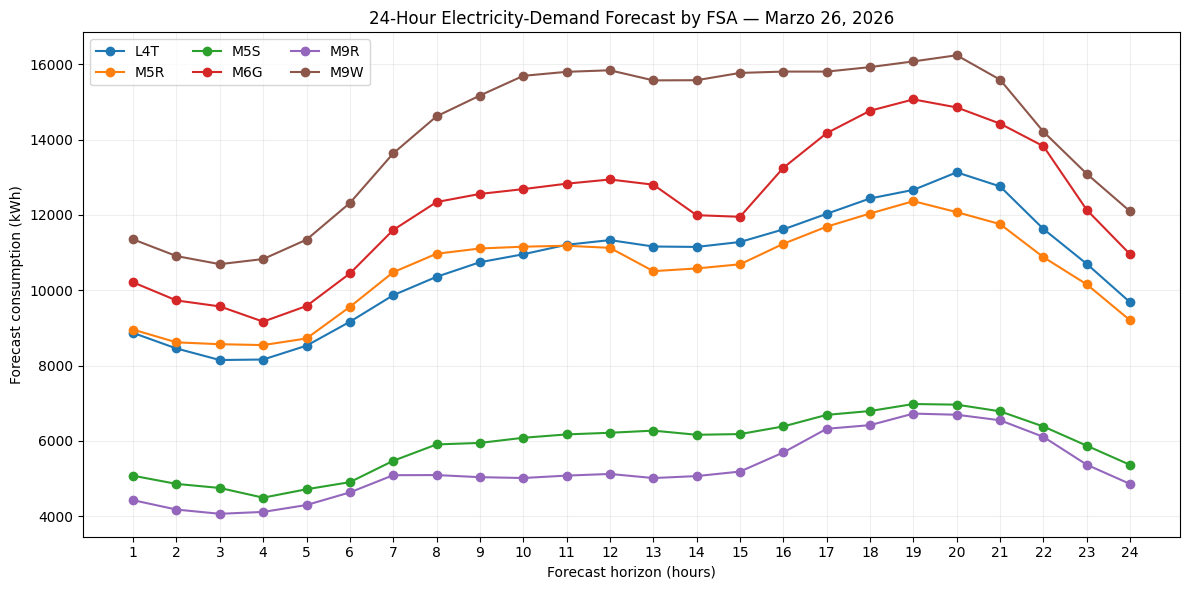

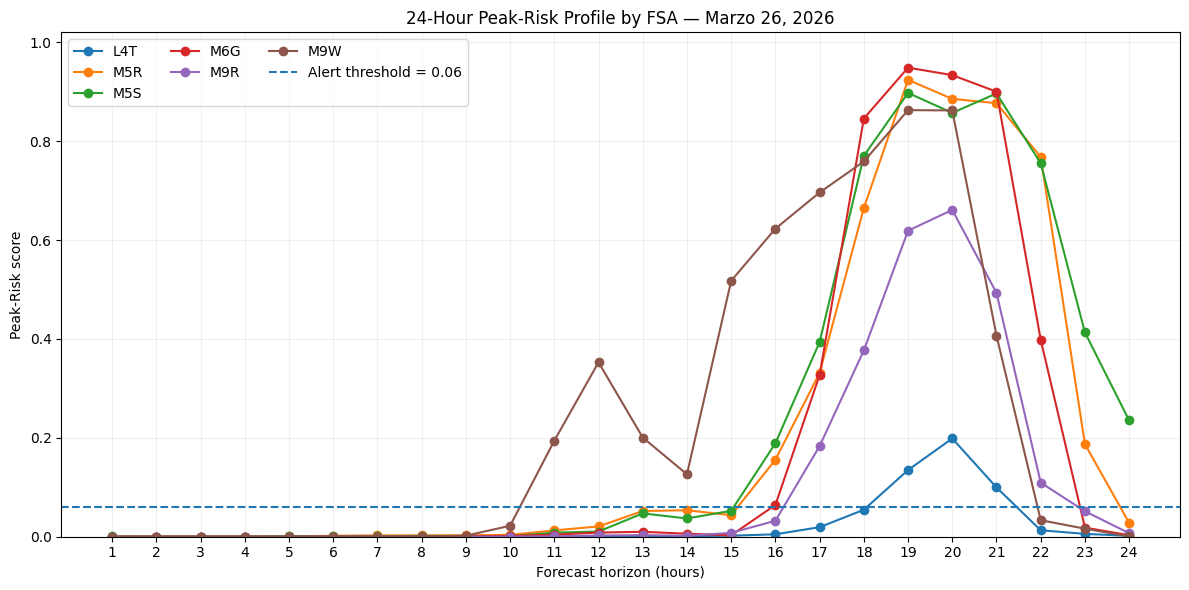

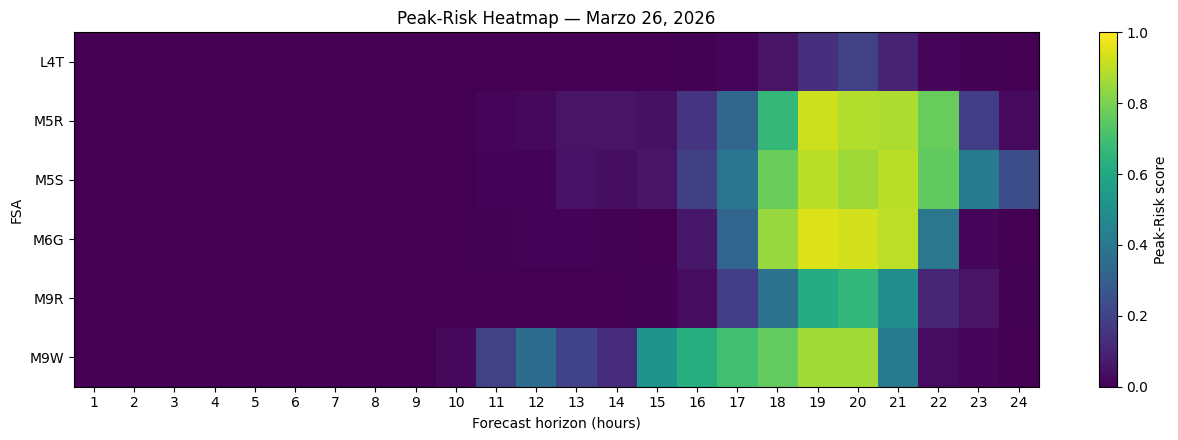

In [10]:
forecast_profile_plot(prediction)
plt.show()

peak_risk_profile_plot(prediction, pipeline.threshold)
plt.show()

peak_risk_heatmap(prediction)
plt.show()


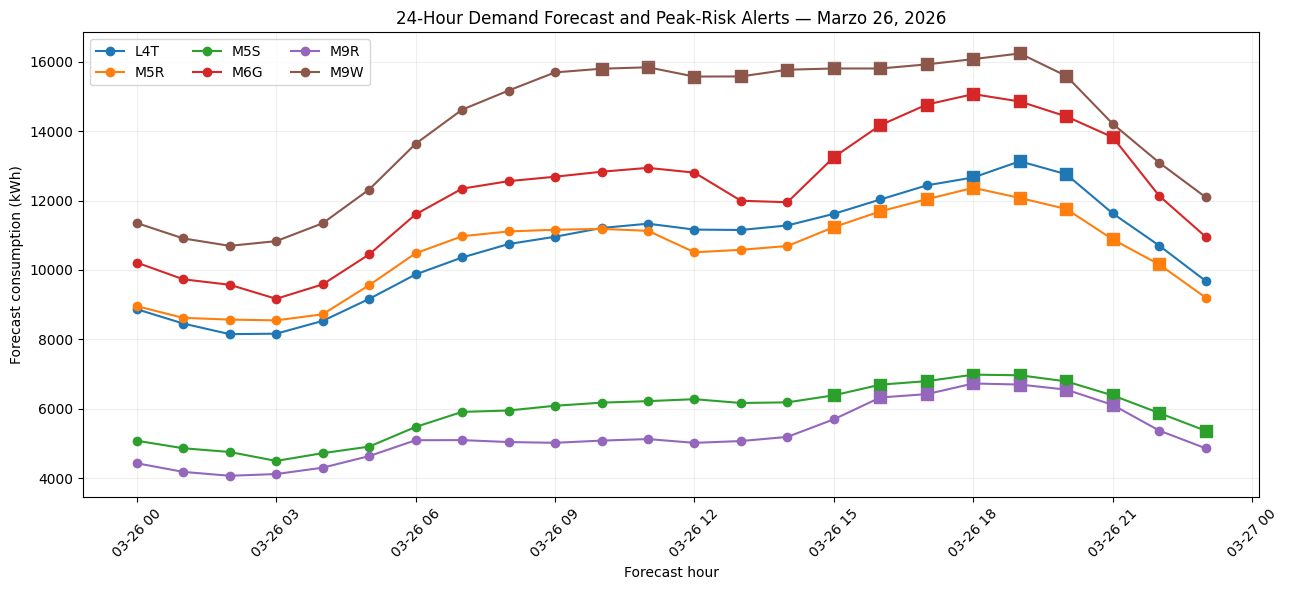

In [15]:
# View Demand and peaks
forecast_with_peak_alerts_plot(prediction)
plt.show()

## Supplementary post-holdout evaluation

If actual demand for the 24 target hours is available, this section compares it with the forecast.

This is **supplementary post-holdout evidence only**. It must not be used to reselect the model, retune hyperparameters, or alter the official 2025 evaluation.


Actual target-hour demand available: 144 / 144
Supplementary 2026 post-holdout metrics:


,rows,mae_kwh,rmse_kwh,mape_pct,wape_pct,bias_kwh
0,144.0,188.453512,247.604333,1.980364,1.939524,72.217313


,fsa,rows,mae_kwh,rmse_kwh,mape_pct,wape_pct,bias_kwh
0,L4T,24.0,148.287621,192.918751,1.352162,1.395114,38.541285
1,M5R,24.0,228.275249,289.212314,2.133712,2.173700,4.568571
2,M5S,24.0,148.039752,172.943544,2.580279,2.574108,142.471458
3,M6G,24.0,296.505606,372.356437,2.449950,2.446886,125.965934
4,M9R,24.0,96.358068,119.853764,1.834033,1.822911,-28.897738
5,M9W,24.0,213.254775,253.105349,1.532046,1.521791,150.654368


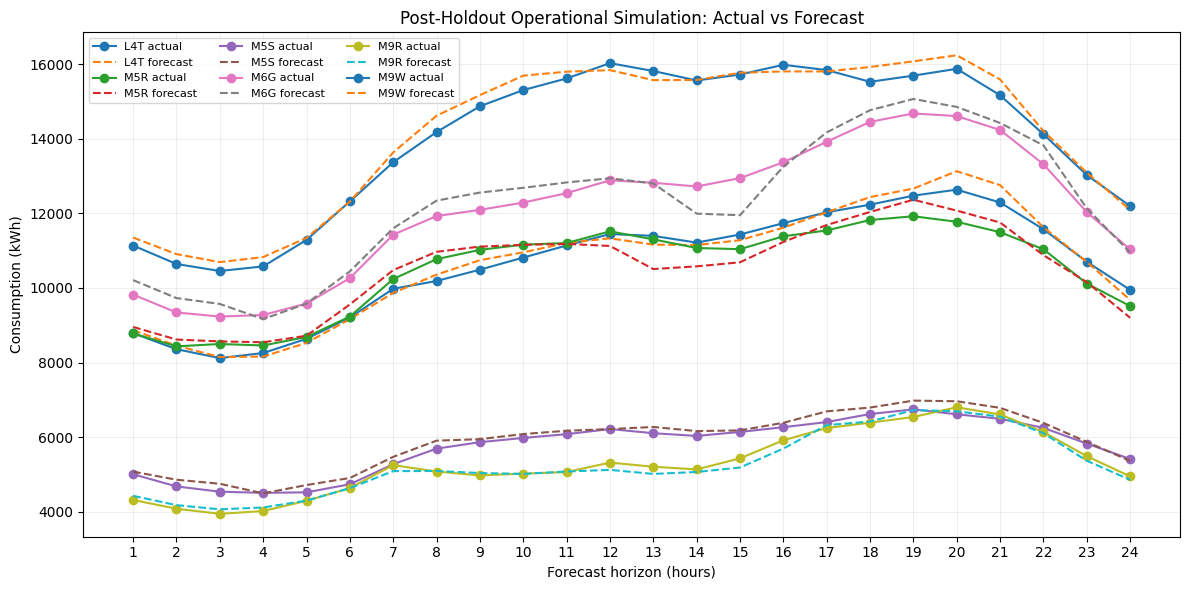

In [11]:
evaluation = pd.DataFrame()
evaluation_global = pd.DataFrame()
evaluation_by_fsa = pd.DataFrame()

if (
    MODE == "operational"
    and COMPARE_WITH_ACTUAL_IF_AVAILABLE
    and not operational_demand_updates.empty
):
    cols = config["columns"]
    actual = operational_demand_updates[
        [cols["fsa"], cols["timestamp"], cols["demand"]]
    ].copy()

    actual = (
        actual.rename(
            columns={
                cols["fsa"]: "fsa",
                cols["timestamp"]: "target_timestamp",
                cols["demand"]: "actual_consumption_kwh",
            }
        )
        .drop_duplicates(["fsa", "target_timestamp"], keep="last")
    )

    evaluation = prediction.merge(
        actual,
        on=["fsa", "target_timestamp"],
        how="left",
        validate="one_to_one",
    )

    complete = evaluation["actual_consumption_kwh"].notna().all()

    print(
        "Actual target-hour demand available:",
        int(evaluation["actual_consumption_kwh"].notna().sum()),
        "/",
        len(evaluation),
    )

    if complete:
        def metrics(frame):
            actual_v = frame["actual_consumption_kwh"].astype(float)
            pred_v = frame["forecast_consumption_kwh"].astype(float)
            error = pred_v - actual_v
            abs_error = error.abs()
            nonzero = actual_v.ne(0)

            return pd.Series({
                "rows": len(frame),
                "mae_kwh": abs_error.mean(),
                "rmse_kwh": np.sqrt((error ** 2).mean()),
                "mape_pct": (
                    (abs_error[nonzero] / actual_v[nonzero].abs()).mean() * 100
                ),
                "wape_pct": abs_error.sum() / actual_v.abs().sum() * 100,
                "bias_kwh": error.mean(),
            })

        evaluation_global = metrics(evaluation).to_frame().T
        evaluation_by_fsa = (
            evaluation.groupby("fsa", observed=True)
            .apply(metrics, include_groups=False)
            .reset_index()
        )

        print("Supplementary 2026 post-holdout metrics:")
        display(evaluation_global)
        display(evaluation_by_fsa)

        actual_vs_forecast_plot(evaluation)
        plt.show()
    else:
        print(
            "Post-holdout accuracy metrics skipped because not all 144 "
            "actual target-hour observations are available."
        )
else:
    print("Post-holdout actual-vs-forecast comparison not requested/available.")


## Save outputs

In [12]:
OUTPUT_DIR = (
    project_root
    / config["paths"]["outputs_dir"]
    / (
        "operational_simulation"
        if MODE == "operational"
        else "historical_replay"
    )
)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

features.to_parquet(
    OUTPUT_DIR / "ifb_model_ready_features.parquet",
    index=False,
)
prediction.to_parquet(
    OUTPUT_DIR / "ifb_integrated_prediction.parquet",
    index=False,
)
prediction.to_csv(
    OUTPUT_DIR / "ifb_integrated_prediction.csv",
    index=False,
)
summary_by_fsa.to_csv(
    OUTPUT_DIR / "ifb_prediction_summary_by_fsa.csv",
    index=False,
)
prediction_validation.to_csv(
    OUTPUT_DIR / "ifb_prediction_validation.csv",
    index=False,
)
runtime_profile.to_csv(
    OUTPUT_DIR / "ifb_runtime_profile.csv",
    index=False,
)

if not evaluation.empty:
    evaluation.to_csv(
        OUTPUT_DIR / "ifb_post_holdout_actual_vs_forecast.csv",
        index=False,
    )
if not evaluation_global.empty:
    evaluation_global.to_csv(
        OUTPUT_DIR / "ifb_post_holdout_metrics_global.csv",
        index=False,
    )
if not evaluation_by_fsa.empty:
    evaluation_by_fsa.to_csv(
        OUTPUT_DIR / "ifb_post_holdout_metrics_by_fsa.csv",
        index=False,
    )

print("IFB_09 outputs saved to:", OUTPUT_DIR)
print("IFB_09 RESULT: PASS")


IFB_09 outputs saved to: E:\jcuenca\OneDrive - GUSCanada\5toTerm\01_Capstone\DataLocal\ontario-electricity-peak-risk\outputs\inference_feature_builder\operational_simulation
IFB_09 RESULT: PASS


## Threshold note

The official Peak-Risk decision threshold remains **0.06** unless `DECISION_THRESHOLD_OVERRIDE` is explicitly set.

Changing only this threshold does **not** retrain Random Forest or XGBoost. The classifier's `peak_risk_score` remains identical; only `peak_alert` changes.

For the Capstone, keep **0.06 as the official frozen threshold**. Alternative thresholds may be displayed later as sensitivity/decision-policy scenarios, but a new official threshold should be revalidated and documented before adoption.
